# RQ1 — Can NLP automatically identify eligibility requirements in art open calls?

**Task.** Classify each sentence ("chunk") of an open call's `requirements_text_en` into one of 11 eligibility labels:
`RESIDENCE`, `NATIONALITY`, `AGE`, `DISCIPLINE`, `CAREER_STAGE`, `EDUCATION`, `STUDENT_STATUS`, `APPLICANT_TYPE`, `PRIOR_FUNDING`, `OTHER_ELIGIBILITY`, `NONE`
(definitions and edge-case rules: `ANNOTATION_GUIDELINES.md`).

**Data.** `dataset/labels/eligibility_annotations.csv` — 696 labeled chunks from 231 opportunities, 15–204 chunks per class, from three annotation rounds (round 2 human-reviewed in part, Cohen's kappa 0.675; round 3's review is pending — see `ANNOTATION_GUIDELINES.md` §6).

**Round 3 (taxonomy revision).** The first two rounds used 9 classes. The per-class results showed the errors concentrated in the catch-all `OTHER_ELIGIBILITY` (20% of chunks, 0.62 F1), which turned out to hold two recurring concepts: *applicant type* (individual vs. organisation, legal form) and *prior funding* (previous or current grants, rejections). They are now classes of their own, and `NONE` has a one-question test (*does the sentence exclude anyone from applying?*). Round-2 scores (9 classes, 678 chunks) are kept in brackets in the conclusion for reference; they are not strictly comparable, since macro-F1 now averages over 11 classes.

**Validation.** 5-fold `StratifiedGroupKFold`, grouped by opportunity, so no call's chunks are split across train and test.
Headline metric: macro-F1, which weights every class equally despite the imbalance.

**Models**, each compared on the same folds:

| # | Model | Role |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | baseline, product candidate |
| 2 | TF-IDF + Linear SVM | product candidate |
| 3 | Sentence embeddings (`bge-base-en-v1.5`) + Logistic Regression | product candidate |
| 4 | OpenAI LLM, few-shot | reference point only, not a product candidate |

The baseline's error analysis comes right after model 1: it drove a label audit and the removal of heading chunks (`ANNOTATION_GUIDELINES.md` §6), and it explains why model 3 was expected to help.


In [1]:
import os

import pandas as pd

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "labels", "eligibility_annotations.csv")

df = pd.read_csv(DATA_PATH)
df.shape

(696, 6)

In [2]:
df["label"].value_counts()

label
NONE                 207
DISCIPLINE            94
APPLICANT_TYPE        77
CAREER_STAGE          76
RESIDENCE             74
STUDENT_STATUS        37
NATIONALITY           31
OTHER_ELIGIBILITY     30
PRIOR_FUNDING         30
AGE                   25
EDUCATION             15
Name: count, dtype: int64

In [3]:
df.groupby("opportunity_id").size().sort_values(ascending=False).head(10)

opportunity_id
mondriaan_fund_e52bef22781c                    22
mondriaan_fund_bccb4029c0d9                    16
national_culture_fund_bulgaria_8fca12fac738    15
kunsten_be_flanders_6f9b625b869d               14
kulturdirektoratet_norway_e1b48f36972d         14
kulturdirektoratet_norway_25c45f0fbcb7         14
creative_ireland_b4833a165cef                  12
fpu_slovakia_7d1dec061d0c                      11
dgartes_portugal_111bdc1e2ebf                  10
kunsten_be_flanders_399ae984ab54                9
dtype: int64

In [4]:
# 5 folds, grouped by opportunity so no call's chunks split across train/test
from sklearn.model_selection import StratifiedGroupKFold

X = df["chunk_text"]
y = df["label"]
groups = df["opportunity_id"]

# needs both: GroupKFold alone ignores the 9-class imbalance, StratifiedKFold alone
# would leak an opportunity's shared phrasing across train/test
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
# NOTE (round 3): one split is used for tuning and error analysis below, but its
# score depends on which calls land in which fold - and StratifiedGroupKFold
# reshuffles folds whenever labels change. The headline comparison is therefore
# repeated over 10 fold seeds ("Robust comparison" cell).

In [5]:
all_labels = set(y.unique())

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    train_groups = set(groups.iloc[train_idx])   # distinct opportunities in train
    test_groups = set(groups.iloc[test_idx])     # distinct opportunities in test
    overlap = train_groups & test_groups          # opportunities present on both sides
    assert not overlap, f"fold {fold}: group leakage on {overlap}"

    # smallest classes (EDUCATION=15, AGE=25) may still miss a fold's test split
    missing = all_labels - set(y.iloc[test_idx])
    print(f"fold {fold}: train={len(train_idx):3d}  test={len(test_idx):3d}  "
          f"missing_from_test={sorted(missing) or 'none'}")

fold 0: train=557  test=139  missing_from_test=none
fold 1: train=556  test=140  missing_from_test=none
fold 2: train=557  test=139  missing_from_test=none
fold 3: train=557  test=139  missing_from_test=none
fold 4: train=557  test=139  missing_from_test=none


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_text = df[["chunk_text"]]  # DataFrame, not Series — ColumnTransformer needs a column name to select

baseline = Pipeline([
    # single-column selector: ColumnTransformer hands TfidfVectorizer a 1D array when given a bare column name
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.1, 1, 10],
}

# scoring=f1_macro, not accuracy — every class weighted equally despite the 6.5x imbalance
grid = GridSearchCV(baseline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_text, y, groups=groups)

print("best params:", grid.best_params_)
print("best macro-F1 (mean over folds):", grid.best_score_)

best params: {'clf__C': 10, 'features__tfidf__min_df': 2, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.6556986860925922


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# out-of-fold predictions for the whole corpus, using the best hyperparameters found above
y_pred = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, y_pred))

# ANNOTATION_GUIDELINES.md §2 menu order, for a readable confusion matrix
LABEL_ORDER = ["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
               "EDUCATION", "STUDENT_STATUS", "APPLICANT_TYPE", "PRIOR_FUNDING",
               "OTHER_ELIGIBILITY", "NONE"]

cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)
pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)

                   precision    recall  f1-score   support

              AGE       0.88      0.88      0.88        25
   APPLICANT_TYPE       0.69      0.58      0.63        77
     CAREER_STAGE       0.70      0.78      0.74        76
       DISCIPLINE       0.66      0.68      0.67        94
        EDUCATION       0.71      0.33      0.45        15
      NATIONALITY       0.83      0.61      0.70        31
             NONE       0.69      0.74      0.71       207
OTHER_ELIGIBILITY       0.33      0.23      0.27        30
    PRIOR_FUNDING       0.58      0.70      0.64        30
        RESIDENCE       0.70      0.73      0.72        74
   STUDENT_STATUS       0.77      0.81      0.79        37

         accuracy                           0.69       696
        macro avg       0.69      0.64      0.66       696
     weighted avg       0.69      0.69      0.68       696



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,APPLICANT_TYPE,PRIOR_FUNDING,OTHER_ELIGIBILITY,NONE
RESIDENCE,54,1,0,1,2,1,0,2,0,2,11
NATIONALITY,3,19,0,2,1,0,1,0,0,1,4
AGE,0,0,22,2,0,0,0,0,0,0,1
DISCIPLINE,3,0,1,64,6,0,0,3,0,5,12
CAREER_STAGE,2,0,2,4,59,0,2,1,0,1,5
EDUCATION,0,0,0,1,3,5,3,1,0,1,1
STUDENT_STATUS,0,1,0,0,2,1,30,0,0,0,3
APPLICANT_TYPE,3,0,0,6,2,0,1,45,3,1,16
PRIOR_FUNDING,0,0,0,1,1,0,0,0,21,0,7
OTHER_ELIGIBILITY,3,0,0,5,3,0,0,1,2,7,9


In [8]:
# Known limitations of this TF-IDF baseline behind the NONE <-> DISCIPLINE errors
# (bare-heading chunks, a third cause, were removed from the data - ANNOTATION_GUIDELINES.md SS6):
#  1. arts vocabulary in non-constraint sentences - project/delivery descriptions
#     ("work with ... arts, cultural or creative organisations") are NONE but share
#     DISCIPLINE's words; bag-of-words can't tell "the project involves X" from
#     "the applicant must be X"
#  2. discipline terms too rare to learn - "early music", "costume designers",
#     "circus artists" appear once or twice in the corpus, and TF-IDF has no notion
#     that "dancers" ~ "performers", so an unseen term carries no signal -> NONE
# both motivate the sentence-embedding classifier; see flows.md, "Eligibility classifier"
# the confusion matrix's densest error cluster: DISCIPLINE / OTHER_ELIGIBILITY / NONE mixing with each other
confused = {"NONE", "DISCIPLINE", "OTHER_ELIGIBILITY"}
errors = df.assign(pred=y_pred)
errors = errors[(errors["label"] != errors["pred"])
                & errors["label"].isin(confused) & errors["pred"].isin(confused)]

for (true_label, pred_label), group in errors.groupby(["label", "pred"]):
    print(f"\n=== true={true_label}  predicted={pred_label}  (n={len(group)}) ===")
    for text in group["chunk_text"].head(3):
        print(f"  - {text}")


=== true=DISCIPLINE  predicted=NONE  (n=12) ===
  - For the ‘Dress-up’ part of our party, we welcome fashion- & costume designers to send a proposal of a selection of pieces/ costumes (from their oeuvre) to be used during the Dress-Up-Tea-Party.
  - You work with early music
  - Work grant (target language German)

=== true=DISCIPLINE  predicted=OTHER_ELIGIBILITY  (n=5) ===
  - Marta & Kim are searching for a total of 2 additional performers, who meet the following conditions:
  - Limitation is the Audiovisual sector (MEDIA).
  - You can come from the arts and culture sector or from other fields and sectors, as long as arts and/or culture play a central role in the initiative.

=== true=NONE  predicted=DISCIPLINE  (n=11) ===
  - Specifically, the workshop is intended for those who:
  - Support is not intended for: accompanying events that are not related to the original focus, projects aimed exclusively at education or research, unsystematic events without regard to artistic or profes

In [9]:
pd.set_option("display.max_colwidth", 120)

# confident-error ranking: misclassifications where the model was most sure of a
# *different* label are the best candidates for a real annotation mistake, not
# just a hard/ambiguous chunk the model was unsure about
proba = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups,
                           method="predict_proba", n_jobs=-1)
classes = grid.best_estimator_.classes_
confidence = proba.max(axis=1)
pred_label = classes[proba.argmax(axis=1)]

review = df.assign(pred=pred_label, confidence=confidence)
review = review[review["label"] != review["pred"]].sort_values("confidence", ascending=False)
review[["chunk_id", "chunk_text", "label", "pred", "confidence"]].head(20)

,chunk_id,chunk_text,label,pred,confidence
670,nordic_culture_fund_ae44e082f513_9c,"Your collaborative partner (an artist(s), arts practitioner(s), or an organisation) must be based in the opposing re...",OTHER_ELIGIBILITY,RESIDENCE,0.969051
680,kulturdirektoratet_norway_90b336625576_1,We normally do not grant funding to enterprises with fixed annual government subsidies.,APPLICANT_TYPE,PRIOR_FUNDING,0.870865
5,nordic_culture_point_99a3ce7db217_4,"The network must consist of partners from: at least three Nordic and/or Baltic countries (Denmark, Estonia, Finland,...",OTHER_ELIGIBILITY,RESIDENCE,0.728997
651,kulturdirektoratet_norway_ab56b6e4b29a_4,We do not provide grants if you already receive operational grants for established enterprises from other schemes in...,PRIOR_FUNDING,NONE,0.703319
405,kunsten_be_flanders_2fa2a89c4a72_0,"The open call is open to anyone who considers themselves a young/starting artist, regardless of age.",CAREER_STAGE,AGE,0.703256
36,kunsten_be_flanders_1c78c30f66d3_0,"Eligible for support are Dutch-Belgian co-projects across all disciplines, but special attention is given to the per...",RESIDENCE,DISCIPLINE,0.698257
665,kunsten_be_flanders_17c494c11db3_0,"Through an EFFEA Residency, festivals join hands to foster the success of emerging artists.",NONE,CAREER_STAGE,0.686421
304,creative_ireland_b4833a165cef_18,Individuals with a local authority (in Strand 3 only),NONE,APPLICANT_TYPE,0.685398
607,kunsten_be_flanders_1e4f87dbc5b9_1,"Applications submitted by individuals, legal entities registered both in Ukraine and abroad, related to the aggresso...",NATIONALITY,OTHER_ELIGIBILITY,0.658477
296,creative_ireland_b4833a165cef_6,Arts and cultural organisations or institutions,NONE,APPLICANT_TYPE,0.656475


In [10]:
# ---- Model 2: Linear SVM ----
# Same pipeline and the same folds as the baseline - only the classifier changes,
# so any score difference comes from the model, not from the features or the split.
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    # LinearSVC instead of LogisticRegression: it looks for the widest margin between
    # classes rather than modelling probabilities - often a bit stronger on sparse,
    # high-dimensional TF-IDF text. Same class_weight="balanced" for the imbalance.
    # max_iter raised because large C values can otherwise stop before converging.
    ("clf", LinearSVC(class_weight="balanced", max_iter=10000)),
])

# same TF-IDF grid as the baseline; C gets one extra value on each side, because the
# baseline's best C=10 sat at the edge of its grid and the SVM's C scales differently.
# History: on round 1's 292 chunks the best C sat on the grid edge (C=100), on a plateau -
# with so few chunks the classes were trivially separable and regularisation stopped
# mattering. On the final 678 chunks the optimum is inside the grid (C=0.1), so the
# grid is wide enough.
svm_param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

svm_grid = GridSearchCV(svm, svm_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
svm_grid.fit(X_text, y, groups=groups)

print("best params:", svm_grid.best_params_)
print("best macro-F1 (mean over folds):", svm_grid.best_score_)


best params: {'clf__C': 1, 'features__tfidf__min_df': 2, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.6440656296826077


In [11]:
# out-of-fold predictions with the best SVM, reported exactly like the baseline above
svm_pred = cross_val_predict(svm_grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, svm_pred))

svm_cm = confusion_matrix(y, svm_pred, labels=LABEL_ORDER)
pd.DataFrame(svm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.82      0.92      0.87        25
   APPLICANT_TYPE       0.65      0.56      0.60        77
     CAREER_STAGE       0.73      0.80      0.76        76
       DISCIPLINE       0.73      0.68      0.70        94
        EDUCATION       0.50      0.33      0.40        15
      NATIONALITY       0.72      0.68      0.70        31
             NONE       0.70      0.69      0.69       207
OTHER_ELIGIBILITY       0.29      0.20      0.24        30
    PRIOR_FUNDING       0.51      0.70      0.59        30
        RESIDENCE       0.72      0.77      0.75        74
   STUDENT_STATUS       0.70      0.86      0.77        37

         accuracy                           0.68       696
        macro avg       0.64      0.65      0.64       696
     weighted avg       0.68      0.68      0.68       696



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,APPLICANT_TYPE,PRIOR_FUNDING,OTHER_ELIGIBILITY,NONE
RESIDENCE,57,2,0,1,2,1,0,2,1,1,7
NATIONALITY,2,21,0,2,1,0,1,0,0,1,3
AGE,0,0,23,1,0,1,0,0,0,0,0
DISCIPLINE,4,1,1,64,5,0,0,3,1,4,11
CAREER_STAGE,0,0,2,3,61,0,3,0,0,2,5
EDUCATION,0,0,1,0,3,5,4,1,0,0,1
STUDENT_STATUS,0,0,0,0,1,1,32,0,0,0,3
APPLICANT_TYPE,3,0,0,4,2,0,2,43,4,2,17
PRIOR_FUNDING,0,0,0,1,1,0,0,0,21,0,7
OTHER_ELIGIBILITY,3,1,1,5,3,0,0,1,2,6,8


In [12]:
# ---- Model 3: sentence embeddings + Logistic Regression ----
# Step 1: turn every chunk into a 768-number vector that encodes its *meaning*, so
# "dancers" and "performers" land close together even though they share no words -
# exactly what TF-IDF can't do (see the limitations note above).
# fastembed runs the model through ONNX Runtime instead of PyTorch, which has no build
# for this Intel Mac on Python 3.13 - see workflow.MD, "Embedding runtime".
import os

import numpy as np
from fastembed import TextEmbedding

EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"  # English is enough: chunks come from requirements_text_en

# downloaded once (~0.2 GB) into a persistent cache - fastembed's default is the system
# temp dir, which macOS clears, and would force a re-download
embedder = TextEmbedding(EMBEDDING_MODEL, cache_dir=os.path.expanduser("~/.cache/fastembed"))

# Computing all embeddings up front, outside the CV loop, does NOT leak test data into
# training: the model is frozen (never trained here), and each chunk is embedded on its
# own, so a chunk's vector is the same whichever fold it ends up in.
X_emb = np.array(list(embedder.embed(df["chunk_text"].tolist())))
X_emb.shape


/Users/lucatomarelli/personal_projects/open_art/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(696, 768)

In [13]:
# Step 2: the same Logistic Regression as the baseline, now reading embeddings instead
# of TF-IDF word counts - so any difference comes from the representation.
# No TfidfVectorizer / ColumnTransformer: X_emb is already a plain numeric matrix.
# Why LogReg and not the Linear SVM, even though the SVM won on TF-IDF:
#  - keeping the baseline's classifier isolates the effect of the representation
#  - the SVM's edge came from sparse, high-dimensional TF-IDF; embeddings are dense
#  - LogReg gives probabilities (predict_proba) - used for the label audit, and lets the
#    product route low-confidence labels to human review; LinearSVC has none
# Checked once outside this notebook, same embeddings and folds, C in 0.001..1000:
# LogReg 0.707 (C=100) vs LinearSVC 0.695 (C=1), LogReg ahead on 4 of 5 folds
# (round 2, 9 classes: 0.740 vs 0.722, 3 of 5; round 1: 0.723 vs 0.704, 4 of 5).
emb_model = Pipeline([
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000)),
])

# only C to tune - the embedding model itself has no hyperparameters here.
# Wider range than the baseline: embeddings are dense and normalised, so the useful
# C values sit elsewhere than for sparse TF-IDF.
emb_param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100, 1000]}

emb_grid = GridSearchCV(emb_model, emb_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
emb_grid.fit(X_emb, y, groups=groups)

print("best params:", emb_grid.best_params_)
print("best macro-F1 (mean over folds):", emb_grid.best_score_)


best params: {'clf__C': 100}
best macro-F1 (mean over folds): 0.7009689603058418


In [14]:
# Step 3: out-of-fold predictions and the same report as the two models above
emb_pred = cross_val_predict(emb_grid.best_estimator_, X_emb, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, emb_pred))

emb_cm = confusion_matrix(y, emb_pred, labels=LABEL_ORDER)
pd.DataFrame(emb_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.96      0.96      0.96        25
   APPLICANT_TYPE       0.65      0.64      0.64        77
     CAREER_STAGE       0.79      0.79      0.79        76
       DISCIPLINE       0.69      0.71      0.70        94
        EDUCATION       0.71      0.33      0.45        15
      NATIONALITY       0.81      0.81      0.81        31
             NONE       0.76      0.76      0.76       207
OTHER_ELIGIBILITY       0.33      0.20      0.25        30
    PRIOR_FUNDING       0.70      0.77      0.73        30
        RESIDENCE       0.75      0.86      0.81        74
   STUDENT_STATUS       0.80      0.86      0.83        37

         accuracy                           0.74       696
        macro avg       0.72      0.70      0.70       696
     weighted avg       0.73      0.74      0.73       696



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,APPLICANT_TYPE,PRIOR_FUNDING,OTHER_ELIGIBILITY,NONE
RESIDENCE,64,1,0,1,1,0,0,2,0,1,4
NATIONALITY,2,25,0,2,0,0,0,0,0,0,2
AGE,0,1,24,0,0,0,0,0,0,0,0
DISCIPLINE,1,0,0,67,6,1,1,3,0,4,11
CAREER_STAGE,0,0,1,6,60,1,1,0,1,3,3
EDUCATION,1,0,0,2,1,5,3,1,0,1,1
STUDENT_STATUS,0,0,0,0,2,0,32,1,0,0,2
APPLICANT_TYPE,6,1,0,4,0,0,1,49,1,1,14
PRIOR_FUNDING,0,0,0,1,0,0,0,0,23,0,6
OTHER_ELIGIBILITY,4,2,0,3,1,0,0,5,1,6,8


### Does the surrounding text help? (round 3)

A sentence alone can be ambiguous: "Open to visual artists" means one thing under *Who can apply?* and another under *What we offer*. The product always has the whole call, so the classifier can be given each chunk's **previous sentence** or its **nearest preceding heading** (a chunk of ≤ 6 words, or one ending in `:` or `?`) as extra input.

Two ways of adding it were tested once outside this notebook, on the same folds (before the round-3 review):
- **as text**, prepended before embedding ("previous sentence + chunk", "heading: chunk"): 0.542 and 0.674 macro-F1, both clearly *worse* than the chunk alone: the context text dilutes the one sentence being classified;
- **as a second vector** next to the chunk's own (below): the classifier can weight the two separately.


In [15]:
# Context vectors: the chunk's own embedding + the embedding of its previous sentence
# (or of its nearest preceding heading), side by side - 1536 numbers per chunk.
# Chunks are re-located in their source text with the same splitter the annotation
# used (scripts/select_annotation_candidates.py), so every chunk_id's index is its
# position in the call. Missing context (first sentence, no heading) -> a zero vector.
import re
import sys

sys.path.insert(0, os.path.join(REPO_ROOT, "scripts"))
from select_annotation_candidates import split_into_chunks

corpus = pd.read_csv(os.path.join(REPO_ROOT, "dataset", "opportunities.csv")).set_index("id")
CHUNK_ID_RE = re.compile(r"^(.*)_(\d+)[a-z]?$")  # <opportunity_id>_<index>, optional Option-B split suffix


def is_heading(text):
    return len(text.split()) <= 6 or text.rstrip().endswith((":", "?"))


prev_text, heading_text = [], []
for chunk_id in df["chunk_id"]:
    opp, idx = CHUNK_ID_RE.match(chunk_id).group(1), int(CHUNK_ID_RE.match(chunk_id).group(2))
    sentences = split_into_chunks(str(corpus.at[opp, "requirements_text_en"]))
    prev_text.append(sentences[idx - 1] if idx > 0 else "")
    heading_text.append(next((sentences[j] for j in range(idx - 1, -1, -1) if is_heading(sentences[j])), ""))
prev_text, heading_text = pd.Series(prev_text), pd.Series(heading_text)
print(f"chunks with a previous sentence: {(prev_text != '').mean():.0%}, with a heading: {(heading_text != '').mean():.0%}")


def embed_context(texts):
    vectors = np.array(list(embedder.embed([t or " " for t in texts])))
    return vectors * (texts != "").to_numpy()[:, None]  # zero where there is no context


X_prev = np.hstack([X_emb, embed_context(prev_text)])
X_head = np.hstack([X_emb, embed_context(heading_text)])

context_scores = {}
for name, X_ctx in {"chunk only (model 3)": X_emb, "chunk + previous sentence": X_prev,
                    "chunk + heading": X_head}.items():
    g = GridSearchCV(emb_model, emb_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1).fit(X_ctx, y, groups=groups)
    context_scores[name] = [g.cv_results_[f"split{k}_test_score"][g.best_index_] for k in range(5)]
    print(f"{name:28} macro-F1 {g.best_score_:.3f}  (C={g.best_params_['clf__C']})")
print(pd.DataFrame(context_scores).round(3))

# Result: neither beats the chunk alone - the context is dropped, and model 3 stays as it is.
# The heading only exists for about 1 chunk in 5, and the previous sentence is often
# another requirement of a different type, so it adds noise rather than disambiguation.


chunks with a previous sentence: 71%, with a heading: 21%


chunk only (model 3)         macro-F1 0.701  (C=100)


chunk + previous sentence    macro-F1 0.674  (C=10)


chunk + heading              macro-F1 0.684  (C=100)
   chunk only (model 3)  chunk + previous sentence  chunk + heading
0                 0.646                      0.625            0.628
1                 0.656                      0.638            0.622
2                 0.741                      0.658            0.707
3                 0.686                      0.704            0.701
4                 0.777                      0.747            0.763


### Model 3b: a larger embedding model (round 3)

Same classifier, same folds, only the embedding model changes: `bge-large-en-v1.5` (1024 numbers per chunk; a 1.34 GB model file vs 0.22 GB for the quantized `bge-base`, also served by `fastembed`). It answers whether a stronger representation still helps once the labels are cleaner. Embedding 696 chunks with it takes tens of minutes on this CPU, so its vectors are cached in `notebooks/cache/`, like the LLM's answers, and only recomputed if the labeled chunks change.


In [16]:
# ---- Model 3b: bge-large embeddings + the same Logistic Regression ----
LARGE_MODEL = "BAAI/bge-large-en-v1.5"
LARGE_CACHE = os.path.join(REPO_ROOT, "notebooks", "cache", "emb_bge-large-en-v1.5.npz")

cached = np.load(LARGE_CACHE, allow_pickle=True) if os.path.exists(LARGE_CACHE) else None
if cached is not None and list(cached["chunk_text"]) == df["chunk_text"].tolist():
    X_large = cached["X"]
else:  # labeled chunks changed (or no cache): embed again and refresh the cache
    large_embedder = TextEmbedding(LARGE_MODEL, cache_dir=os.path.expanduser("~/.cache/fastembed"))
    X_large = np.array(list(large_embedder.embed(df["chunk_text"].tolist(), batch_size=16)), dtype=np.float32)
    np.savez_compressed(LARGE_CACHE, chunk_id=df["chunk_id"].to_numpy(), chunk_text=df["chunk_text"].to_numpy(), X=X_large)
print("bge-large vectors:", X_large.shape)

large_grid = GridSearchCV(emb_model, emb_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
large_grid.fit(X_large, y, groups=groups)
print("best params:", large_grid.best_params_)
print("best macro-F1 (mean over folds):", large_grid.best_score_)

large_pred = cross_val_predict(large_grid.best_estimator_, X_large, y, cv=cv, groups=groups, n_jobs=-1)
print(classification_report(y, large_pred))


bge-large vectors: (696, 1024)


best params: {'clf__C': 1000}
best macro-F1 (mean over folds): 0.7025917913275714


                   precision    recall  f1-score   support

              AGE       0.96      0.92      0.94        25
   APPLICANT_TYPE       0.60      0.62      0.61        77
     CAREER_STAGE       0.76      0.79      0.77        76
       DISCIPLINE       0.71      0.71      0.71        94
        EDUCATION       0.75      0.40      0.52        15
      NATIONALITY       0.81      0.81      0.81        31
             NONE       0.78      0.75      0.76       207
OTHER_ELIGIBILITY       0.45      0.30      0.36        30
    PRIOR_FUNDING       0.68      0.83      0.75        30
        RESIDENCE       0.73      0.81      0.77        74
   STUDENT_STATUS       0.71      0.81      0.76        37

         accuracy                           0.73       696
        macro avg       0.72      0.71      0.71       696
     weighted avg       0.73      0.73      0.73       696



In [17]:
# ---- Model 4: OpenAI LLM, few-shot (reference point only - NOT a product candidate) ----
# Question it answers: how far are our trained models from a general-purpose LLM that
# was never trained on this data? It is kept out of the product on purpose - the
# classifier must run locally, cheaply and reproducibly.
#
# Step 1: the prompt. The LLM gets the same taxonomy the annotations were made with
# (ANNOTATION_GUIDELINES.md SS2-SS3), so it is judged against rules it was actually told.
from typing import Literal

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel

load_dotenv(os.path.join(REPO_ROOT, ".env"))  # OPENAI_API_KEY, same .env as the pipeline

LLM_MODEL = "gpt-5.4-mini"  # the model the rest of the pipeline already uses
PROMPT_VERSION = "v2"       # bump when the prompt changes, so cached answers aren't reused
                            # (v1: 9-class taxonomy; v2: round 3, 11 classes)
SHOTS_PER_CLASS = 2         # few-shot examples per label, drawn from the training fold only

SYSTEM_PROMPT = """You classify single sentences ("chunks") from art open calls (residencies, \
grants, commissions) by the eligibility requirement they state. Choose exactly one label:

- RESIDENCE: where the applicant lives or is based ("must be based in Germany"). For an \
organisation, a national descriptor means where it is registered/based -> RESIDENCE.
- NATIONALITY: citizenship or passport of an individual ("open to French nationals").
- AGE: an age threshold, range or birth-year cutoff.
- DISCIPLINE: a required artistic medium, practice or field ("visual artists working in \
sculpture"). Not an organisation type.
- CAREER_STAGE: professional stage without an age number ("emerging", "professional artist", \
"at least 5 years of practice").
- EDUCATION: a degree, qualification or academic requirement.
- STUDENT_STATUS: currently enrolled or recently graduated.
- APPLICANT_TYPE: what kind of applicant may apply - individual vs organisation, legal form, \
organisation category (museums, schools, publishers, local authorities), duos or collectives. \
Where an organisation must be registered -> RESIDENCE; an artistic field fused into the \
applicant phrase ("performing arts groups") -> DISCIPLINE.
- PRIOR_FUNDING: the applicant's funding or application history - previous or current grants, \
previous recipients excluded, earlier rejections, prior participation, caps on how often \
support can be received. "Already received public recognition" is CAREER_STAGE.
- OTHER_ELIGIBILITY: a real, checkable constraint that fits none of the above (membership, \
availability, language, conflict of interest, sanctions).
- NONE: not an eligibility constraint - procedures, deadlines, fees, project descriptions, \
what a scheme does not fund, value statements ("we welcome diverse backgrounds"). Test: if \
the sentence excludes no one from applying, it is NONE.

Rules: label the topic of the constraint, not its polarity ("students are not eligible" is \
STUDENT_STATUS). A clause saying a criterion is NOT required ("you do not need to be a \
citizen") gets that criterion's label. If a sentence mixes two topics, pick the most central one."""


class ChunkLabel(BaseModel):
    """Structured output: the API guarantees one of the 11 labels, no free-text parsing."""
    label: Literal["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
                   "EDUCATION", "STUDENT_STATUS", "APPLICANT_TYPE", "PRIOR_FUNDING",
                   "OTHER_ELIGIBILITY", "NONE"]


def few_shot_messages(train_df):
    """SHOTS_PER_CLASS examples per label from the *training* fold, as user/assistant turns."""
    # every class has 8+ chunks in any training fold, so SHOTS_PER_CLASS always fits
    shots = (train_df.groupby("label").sample(n=SHOTS_PER_CLASS, random_state=42)
             .sample(frac=1, random_state=42))  # shuffle, so examples aren't grouped by label
    messages = []
    for _, row in shots.iterrows():
        messages.append({"role": "user", "content": row["chunk_text"]})
        messages.append({"role": "assistant", "content": ChunkLabel(label=row["label"]).model_dump_json()})
    return messages


def classify_chunk(client, shots, text):
    """One API call: system prompt + few-shot examples + the chunk to label."""
    response = client.chat.completions.parse(
        model=LLM_MODEL,
        temperature=0,  # repeatable answers for the same input, as in the rest of the pipeline
        messages=[{"role": "system", "content": SYSTEM_PROMPT}, *shots,
                  {"role": "user", "content": text}],
        response_format=ChunkLabel,
    )
    return response.choices[0].message.parsed.label


In [18]:
# Step 2: run it fold by fold, with the SAME folds as the other three models.
# For each fold the examples come only from that fold's training chunks, and the LLM
# labels that fold's test chunks - so, like the trained models, it never sees a test
# chunk's label. Every answer is cached to disk: re-running the notebook costs nothing,
# and it runs without an API key once the cache is complete.
import json
from concurrent.futures import ThreadPoolExecutor

LLM_CACHE_PATH = os.path.join(REPO_ROOT, "notebooks", "cache", "llm_predictions.jsonl")


def cache_key(fold, chunk_id):
    return f"{LLM_MODEL}|{PROMPT_VERSION}|{fold}|{chunk_id}"


cache = {}
if os.path.exists(LLM_CACHE_PATH):
    with open(LLM_CACHE_PATH) as f:
        cache = {row["key"]: row["label"] for row in map(json.loads, f)}

client = None  # created only if something actually needs to be sent
llm_pred = pd.Series(index=df.index, dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
    shots = few_shot_messages(df.iloc[train_idx])
    todo = [i for i in test_idx if cache_key(fold, df.at[i, "chunk_id"]) not in cache]

    if todo:
        # max_retries: the client backs off and retries on rate-limit (429) errors by itself;
        # the account's limit is 200k tokens/minute, and each call is ~1k tokens
        client = client or OpenAI(max_retries=10)
        # a few requests in parallel - one at a time would take ~10 minutes; more than 4
        # hits the tokens-per-minute limit
        with ThreadPoolExecutor(max_workers=4) as pool:
            labels = list(pool.map(lambda i: classify_chunk(client, shots, df.at[i, "chunk_text"]), todo))
        with open(LLM_CACHE_PATH, "a") as f:  # append after each fold, so an interruption loses little
            for i, label in zip(todo, labels):
                key = cache_key(fold, df.at[i, "chunk_id"])
                cache[key] = label
                f.write(json.dumps({"key": key, "chunk_id": df.at[i, "chunk_id"], "label": label}) + "\n")

    llm_pred.iloc[test_idx] = [cache[cache_key(fold, df.at[i, "chunk_id"])] for i in test_idx]
    print(f"fold {fold}: {len(test_idx)} chunks, {len(todo)} sent to the API, {len(test_idx) - len(todo)} from cache")

llm_pred = llm_pred.to_numpy()


fold 0: 139 chunks, 0 sent to the API, 139 from cache
fold 1: 140 chunks, 0 sent to the API, 140 from cache
fold 2: 139 chunks, 0 sent to the API, 139 from cache
fold 3: 139 chunks, 0 sent to the API, 139 from cache
fold 4: 139 chunks, 0 sent to the API, 139 from cache


In [19]:
# Step 3: the same report as the trained models
print(classification_report(y, llm_pred))

llm_cm = confusion_matrix(y, llm_pred, labels=LABEL_ORDER)
pd.DataFrame(llm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       0.96      0.96      0.96        25
   APPLICANT_TYPE       0.52      0.92      0.67        77
     CAREER_STAGE       0.82      0.80      0.81        76
       DISCIPLINE       0.92      0.62      0.74        94
        EDUCATION       0.67      0.80      0.73        15
      NATIONALITY       1.00      0.68      0.81        31
             NONE       0.88      0.65      0.74       207
OTHER_ELIGIBILITY       0.38      0.70      0.49        30
    PRIOR_FUNDING       0.54      0.87      0.67        30
        RESIDENCE       0.92      0.82      0.87        74
   STUDENT_STATUS       0.86      0.84      0.85        37

         accuracy                           0.75       696
        macro avg       0.77      0.79      0.76       696
     weighted avg       0.81      0.75      0.76       696



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,APPLICANT_TYPE,PRIOR_FUNDING,OTHER_ELIGIBILITY,NONE
RESIDENCE,61,0,0,0,1,0,0,9,0,1,2
NATIONALITY,3,21,0,1,0,0,0,1,0,2,3
AGE,0,0,24,0,0,0,0,1,0,0,0
DISCIPLINE,0,0,1,58,3,0,0,22,0,2,8
CAREER_STAGE,0,0,0,2,61,5,2,2,3,0,1
EDUCATION,0,0,0,0,2,12,1,0,0,0,0
STUDENT_STATUS,0,0,0,0,2,1,31,0,1,0,2
APPLICANT_TYPE,1,0,0,0,0,0,0,71,1,4,0
PRIOR_FUNDING,0,0,0,0,0,0,0,4,26,0,0
OTHER_ELIGIBILITY,1,0,0,0,1,0,0,4,0,21,3


In [20]:
# ---- All models, side by side ----
from sklearn.metrics import f1_score

# name -> out-of-fold predictions; every model was scored on the identical 5 folds
models = {
    "baseline": y_pred,
    "svm": svm_pred,
    "embeddings": emb_pred,
    "emb-large": large_pred,
    "llm (ref)": llm_pred,  # reference only, not a product candidate
}

# 1. per-fold macro-F1, computed from the predictions of each test fold. For the three
#    trained models this reproduces GridSearchCV's own fold scores (same folds, same best
#    parameters); computing it this way also works for the LLM, which has no GridSearchCV.
#    With only ~60 test chunks per fold, a model that wins on average but loses on most
#    folds hasn't really won.
fold_idx = [test_idx for _, test_idx in cv.split(X_text, y, groups)]
folds = pd.DataFrame({
    name: [f1_score(y.iloc[idx], pred[idx], average="macro") for idx in fold_idx]
    for name, pred in models.items()
})
folds.loc["mean"] = folds.mean()
print(folds.round(3), "\n")

# 2. per-class F1: shows *where* one model beats another, not just whether
per_class = pd.DataFrame({
    name: f1_score(y, pred, labels=LABEL_ORDER, average=None) for name, pred in models.items()
}, index=LABEL_ORDER)
print(per_class.round(2), "\n")

# 3. the NONE <-> DISCIPLINE confusion tracked since the baseline (see the limitations note above)
for name, pred in models.items():
    none_as_disc = ((y == "NONE") & (pred == "DISCIPLINE")).sum()
    disc_as_none = ((y == "DISCIPLINE") & (pred == "NONE")).sum()
    print(f"{name:10}  NONE->DISCIPLINE: {none_as_disc:2d}   DISCIPLINE->NONE: {disc_as_none:2d}")

# 4. round 3 changed the taxonomy (9 -> 11 classes), so macro-F1 now averages over two
#    more classes and is not directly comparable with the round-2 scores. Like-for-like:
#    merge the two new classes back into OTHER_ELIGIBILITY in both labels and predictions
#    and score on the old 9 classes. Also shown: macro-F1 without the residual
#    OTHER_ELIGIBILITY, the one class that is heterogeneous by design (~5% of chunks).
TO_9_CLASSES = {"APPLICANT_TYPE": "OTHER_ELIGIBILITY", "PRIOR_FUNDING": "OTHER_ELIGIBILITY"}
y9 = y.replace(TO_9_CLASSES)
print()
for name, pred in models.items():
    pred9 = pd.Series(pred).replace(TO_9_CLASSES)
    without_other = [label for label in LABEL_ORDER if label != "OTHER_ELIGIBILITY"]
    print(f"{name:10}  macro-F1 on 9 classes: {f1_score(y9, pred9, average='macro'):.3f}   "
          f"on 10 (no OTHER_ELIGIBILITY): {f1_score(y, pred, labels=without_other, average='macro'):.3f}   "
          f"accuracy: {(pred == y.to_numpy()).mean():.3f}")


      baseline    svm  embeddings  emb-large  llm (ref)
0        0.669  0.644       0.646      0.622      0.741
1        0.569  0.551       0.656      0.644      0.711
2        0.729  0.707       0.741      0.718      0.753
3        0.582  0.619       0.686      0.729      0.762
4        0.730  0.700       0.777      0.800      0.806
mean     0.656  0.644       0.701      0.703      0.755 

                   baseline   svm  embeddings  emb-large  llm (ref)
RESIDENCE              0.72  0.75        0.81       0.77       0.87
NATIONALITY            0.70  0.70        0.81       0.81       0.81
AGE                    0.88  0.87        0.96       0.94       0.96
DISCIPLINE             0.67  0.70        0.70       0.71       0.74
CAREER_STAGE           0.74  0.76        0.79       0.77       0.81
EDUCATION              0.45  0.40        0.45       0.52       0.73
STUDENT_STATUS         0.79  0.77        0.83       0.76       0.85
APPLICANT_TYPE         0.63  0.60        0.64       0.61      

embeddings  macro-F1 on 9 classes: 0.751   on 10 (no OTHER_ELIGIBILITY): 0.748   accuracy: 0.737
emb-large   macro-F1 on 9 classes: 0.743   on 10 (no OTHER_ELIGIBILITY): 0.740   accuracy: 0.730
llm (ref)   macro-F1 on 9 classes: 0.801   on 10 (no OTHER_ELIGIBILITY): 0.785   accuracy: 0.747


### Robust comparison: 10 fold seeds (round 3)

Everything above uses one fold split (`random_state=42`). Round 3 showed why that isn't enough for the headline:
- **The split is favourable.** Over 10 split seeds, the same models score up to ~0.03 lower on average.
- **The split moves with the labels.** `StratifiedGroupKFold` assigns folds using the labels, so a handful of label edits reshuffles most folds, and the score can move by more than the edits themselves justify.

So each trained model is re-run over 10 seeds with the hyperparameters its grid search picked above, and reported as mean ± std. The same seeds and folds are used for every model. Fixing the hyperparameters from the seed-42 search is a small optimistic bias, and the same for all models. The LLM reference is not repeated, since that would take ~7,000 more API calls; its single-split score is comparable with the seed-42 column, not with the mean.


In [21]:
# ---- Robust comparison: every trained model over 10 fold seeds ----
SEEDS = range(10)
robust_models = {
    "TF-IDF + LogReg (baseline)": (grid.best_estimator_, X_text),
    "TF-IDF + Linear SVM": (svm_grid.best_estimator_, X_text),
    "bge-base + LogReg": (emb_grid.best_estimator_, X_emb),
    "bge-large + LogReg": (large_grid.best_estimator_, X_large),
}

rows = []
for seed in SEEDS:
    seed_cv = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed).split(X_text, y, groups))
    for name, (estimator, X_all) in robust_models.items():
        pred = pd.Series(cross_val_predict(estimator, X_all, y, cv=seed_cv, groups=groups, n_jobs=-1))
        rows.append({
            "model": name, "seed": seed,
            # mean of the 5 fold scores, like GridSearchCV's best_score_
            "macro_f1_11": np.mean([f1_score(y.iloc[t], pred.iloc[t], average="macro") for _, t in seed_cv]),
            "macro_f1_9": np.mean([f1_score(y9.iloc[t], pred.iloc[t].replace(TO_9_CLASSES), average="macro") for _, t in seed_cv]),
            "accuracy": (pred == y).mean(),
        })

robust = pd.DataFrame(rows)
summary = robust.groupby("model", sort=False).agg(["mean", "std"]).drop(columns="seed")
print(summary.round(3).to_string())

# seed 42, as reported in the single-split cells above - for comparison with the LLM reference
print("\nseed 42 only (the single split above, mean of its 5 folds):",
      folds.loc["mean"].round(3).to_dict())


                           macro_f1_11        macro_f1_9        accuracy       
                                  mean    std       mean    std     mean    std
model                                                                          
TF-IDF + LogReg (baseline)       0.650  0.016      0.693  0.018    0.689  0.012
TF-IDF + Linear SVM              0.646  0.016      0.696  0.016    0.683  0.012
bge-base + LogReg                0.701  0.012      0.747  0.013    0.736  0.007
bge-large + LogReg               0.708  0.010      0.755  0.008    0.743  0.007

seed 42 only (the single split above, mean of its 5 folds): {'baseline': 0.656, 'svm': 0.644, 'embeddings': 0.701, 'emb-large': 0.703, 'llm (ref)': 0.755}


In [22]:
# ---- Confidence threshold: which labels can the product trust, which go to review? ----
# The chosen model gives a probability per class. A chunk whose top probability is low is
# more likely wrong, so the product shows it to the artist for a check instead of using
# it silently. The threshold is picked from out-of-fold probabilities - the same folds as
# everything above - so it reflects chunks from calls the model never saw.
chosen_proba = cross_val_predict(emb_grid.best_estimator_, X_emb, y, cv=cv, groups=groups,
                                 method="predict_proba", n_jobs=-1)
chosen_classes = emb_grid.best_estimator_.classes_  # predict_proba's column order
top_p = chosen_proba.max(axis=1)
top_label = chosen_classes[chosen_proba.argmax(axis=1)]
correct = top_label == y.to_numpy()

rows = []
for t in [0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    kept = top_p >= t
    rows.append({"threshold": t,
                 "auto_accepted": kept.mean(),          # share of chunks the product trusts as-is
                 "accuracy_accepted": correct[kept].mean(),
                 "accuracy_to_review": correct[~kept].mean() if (~kept).any() else np.nan})
thresholds = pd.DataFrame(rows)
print(thresholds.round(3).to_string(index=False))

# Target: accepted labels at least as reliable as a second human annotator would make them.
# The only measured reference is human-vs-pre-label agreement (74% raw on round 2), so 85%
# accuracy on the accepted share is a deliberately stricter bar; the lowest threshold that
# reaches it keeps the review load as small as possible.
TARGET_ACCURACY = 0.85
ok = thresholds[(thresholds["threshold"] > 0) & (thresholds["accuracy_accepted"] >= TARGET_ACCURACY)]
REVIEW_THRESHOLD = float(ok["threshold"].min()) if len(ok) else None
if REVIEW_THRESHOLD is not None:
    row = thresholds.set_index("threshold").loc[REVIEW_THRESHOLD]
    print(f"\nthreshold {REVIEW_THRESHOLD}: {row['auto_accepted']:.0%} of chunks auto-accepted at "
          f"{row['accuracy_accepted']:.0%} accuracy, {1 - row['auto_accepted']:.0%} sent to review")


 threshold  auto_accepted  accuracy_accepted  accuracy_to_review
       0.0          1.000              0.737                 NaN
       0.3          0.986              0.741               0.500
       0.4          0.941              0.768               0.244
       0.5          0.875              0.793               0.345
       0.6          0.767              0.831               0.426
       0.7          0.671              0.854               0.498
       0.8          0.550              0.890               0.550
       0.9          0.418              0.921               0.605

threshold 0.7: 67% of chunks auto-accepted at 85% accuracy, 33% sent to review


                     model  fraction  train_chunks  mean_f1  std_f1
       Embeddings + LogReg      0.25        146.48    0.566   0.061
       Embeddings + LogReg      0.50        283.72    0.638   0.058
       Embeddings + LogReg      0.75        415.28    0.676   0.058
       Embeddings + LogReg      1.00        556.80    0.702   0.055
TF-IDF + LogReg (baseline)      0.25        146.48    0.451   0.069
TF-IDF + LogReg (baseline)      0.50        283.72    0.556   0.063
TF-IDF + LogReg (baseline)      0.75        415.28    0.609   0.069
TF-IDF + LogReg (baseline)      1.00        556.80    0.656   0.077


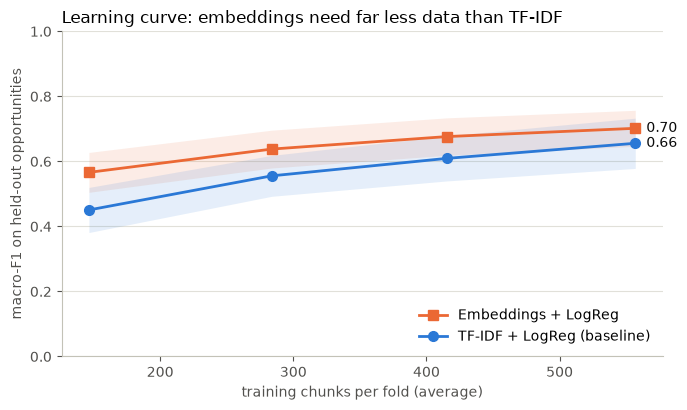

In [23]:
# ---- Learning curve: would more annotated data help? ----
# For each CV fold, train on a random 25 / 50 / 75 / 100 % of that fold's training
# *opportunities* (whole calls, never single chunks, same logic as the grouped CV), then
# score on the untouched test fold. Each smaller share is drawn 5 times with different
# seeds and averaged, so one lucky or unlucky subset doesn't decide the point.
import matplotlib.pyplot as plt
from sklearn.base import clone

FRACTIONS = [0.25, 0.5, 0.75, 1.0]
N_DRAWS = 5

# the two tuned models from above, with the hyperparameters their grid searches picked
curve_models = {
    "TF-IDF + LogReg (baseline)": (grid.best_estimator_, X_text),
    "Embeddings + LogReg": (emb_grid.best_estimator_, X_emb),
}

curve_rows = []
for name, (estimator, X_all) in curve_models.items():
    for frac in FRACTIONS:
        for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
            for draw in range(N_DRAWS if frac < 1 else 1):  # 100% has only one possible "subset"
                rng = np.random.default_rng(draw)
                train_opps = groups.iloc[train_idx].unique()
                kept = rng.choice(train_opps, size=round(frac * len(train_opps)), replace=False)
                sub_idx = train_idx[groups.iloc[train_idx].isin(kept).to_numpy()]

                model = clone(estimator).fit(X_all[sub_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[sub_idx],
                                             y.iloc[sub_idx])
                X_test = X_all[test_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[test_idx]
                curve_rows.append({
                    "model": name, "fraction": frac, "train_chunks": len(sub_idx),
                    # zero_division=0: a small subset can miss a class entirely - that
                    # class then scores 0, which is exactly the cost of too little data
                    "macro_f1": f1_score(y.iloc[test_idx], model.predict(X_test),
                                         labels=LABEL_ORDER, average="macro", zero_division=0),
                })

curve = (pd.DataFrame(curve_rows)
         .groupby(["model", "fraction"])
         .agg(train_chunks=("train_chunks", "mean"), mean_f1=("macro_f1", "mean"), std_f1=("macro_f1", "std"))
         .reset_index())
print(curve.round(3).to_string(index=False))

# ---- plot: one line per model, shaded band = +/- 1 std across folds and draws ----
COLORS = {"TF-IDF + LogReg (baseline)": "#2a78d6", "Embeddings + LogReg": "#eb6834"}  # validated pair (CVD-safe)
MARKERS = {"TF-IDF + LogReg (baseline)": "o", "Embeddings + LogReg": "s"}               # second cue beside colour

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, part in curve.groupby("model"):
    ax.fill_between(part["train_chunks"], part["mean_f1"] - part["std_f1"], part["mean_f1"] + part["std_f1"],
                    color=COLORS[name], alpha=0.12, linewidth=0)
    ax.plot(part["train_chunks"], part["mean_f1"], color=COLORS[name], marker=MARKERS[name],
            markersize=7, linewidth=2, label=name)
    last = part.iloc[-1]  # direct label at the line end, in text colour (not the series colour)
    ax.annotate(f"{last['mean_f1']:.2f}", (last["train_chunks"], last["mean_f1"]),
                xytext=(8, 0), textcoords="offset points", va="center", color="#0b0b0b", fontsize=10)

ax.set_xlabel("training chunks per fold (average)", color="#52514e")
ax.set_ylabel("macro-F1 on held-out opportunities", color="#52514e")
ax.set_title("Learning curve: embeddings need far less data than TF-IDF", loc="left", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)  # recessive horizontal grid only
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# Reading it (round 3, 11 classes):
#  - embeddings are far ahead where data is scarce (0.57 vs 0.45 at a quarter of the
#    data); with half the chunks (~284, 0.64) they nearly match TF-IDF with all of them
#    (0.66)
#  - the embeddings curve keeps flattening (+0.07, then +0.04, then +0.03 per step):
#    more of the same data adds little
#  - history: this curve on round 1's 292 chunks motivated round 2; on round 2's 678
#    chunks it had flattened, which motivated revising the taxonomy (round 3)


## Conclusion

*Snapshot on the committed annotation file after round 3 (696 chunks, 11 classes, human-reviewed and adjudicated). Headline numbers are the **mean ± std over 10 fold seeds** ("Robust comparison" cell); the LLM reference was run on one split only (seed 42).*

| Model | Macro-F1, 11 classes | Macro-F1, old 9 classes* | Accuracy |
|---|---|---|---|
| TF-IDF + LogReg (baseline) | 0.650 ± 0.016 | 0.693 | 0.69 |
| TF-IDF + Linear SVM | 0.646 ± 0.016 | 0.696 | 0.68 |
| **Embeddings (bge-base) + LogReg — chosen** | **0.701 ± 0.012** | **0.747** | **0.74** |
| Embeddings (bge-large) + LogReg | 0.708 ± 0.010 | 0.755 | 0.74 |
| *OpenAI LLM, few-shot (reference, seed 42 only)* | *0.755* | *0.801* | *0.75* |

\* `APPLICANT_TYPE` and `PRIOR_FUNDING` merged back into `OTHER_ELIGIBILITY`, for comparison with the 9-class rounds.

**Answer to RQ1: yes.** A local model identifies the eligibility requirement stated in a chunk with 74% accuracy across 11 classes (0.70 macro-F1, 0.75 on the original 9), validated on opportunities it never saw during training.

**Chosen model: bge-base embeddings + Logistic Regression.**
- Best trained model after bge-large, ahead of the TF-IDF baseline by ~0.05 macro-F1 on every seed.
- bge-large is only ~0.01 better, within about one standard deviation, for a ~6× larger model file (1.34 GB vs 0.22 GB) and much slower CPU embedding. Not worth it for the product.
- LogReg gives probabilities: with a 0.7 confidence threshold, 67% of chunks are auto-accepted at 85% accuracy and the other 33% go to the artist for review.

**What round 3 (taxonomy revision) did and didn't do.**
- It did **not** make the task easier to learn. On the same 678 chunks and the same folds, the revised labels score the same as round 2's once merged back to 9 classes (0.737 vs 0.743, within noise). An earlier single-split reading suggested +0.025; that was split luck.
- It **did** make the output more useful: the eligibility engine gets *applicant type* and *prior funding* as separate, checkable signals (0.64 and 0.73 F1), and the catch-all shrank from 20% of chunks to 4%. What remains in `OTHER_ELIGIBILITY` is heterogeneous by design and stays the weakest class (~0.25–0.36).
- Adding context (previous sentence, nearest heading) did not help, whether as text or as a second vector.

**Evaluation lesson.** One fold split is not a stable measurement at this data size. `StratifiedGroupKFold` reshuffles folds whenever labels change, and seed 42 happened to be ~0.03 more favourable than the average. Comparisons made on it overstated gains. Reporting mean ± std over 10 seeds fixed this.

**The LLM reference.** It stays ahead (0.755 vs 0.701 on the same seed-42 split; 0.80 on 9 classes), most visibly on `EDUCATION` and `OTHER_ELIGIBILITY`, the two classes with the least training data. The product still uses the local model by design: deterministic, zero per-call cost, runs locally. The gap is the measured price of that choice, about 0.05 macro-F1 and 1 point of accuracy.

**Limitations.**
- Label consistency is the ceiling. Human-vs-pre-label agreement was kappa 0.675 (round 2) and 0.590 (round 3, a smaller and harder sample). Disagreements cluster on organisation types (APPLICANT_TYPE vs RESIDENCE / DISCIPLINE) and on EDUCATION / STUDENT_STATUS / CAREER_STAGE.
- Most labels were applied by an LLM session following the guidelines and then reviewed in part, so the LLM reference may be slightly flattered (agreement bias).
- Hyperparameters were picked on seed 42 and reused for the 10-seed comparison: a small, shared optimistic bias.
- `PRIOR_FUNDING` contains near-identical boilerplate from one source, which somewhat flatters that class. `EDUCATION` has 15 chunks, all the degree requirements this corpus holds.
- Headings are excluded from the training data, so the production chunker must drop them before classification.

Full reasoning, per-step decisions and caveats: `flows.md` ("Eligibility classifier"), `workflow.MD` ("RQ1 improvement plan") and `ANNOTATION_GUIDELINES.md` §6.


## Final model

Cross-validation chose the model and its hyperparameters; the version the product uses is refit on **every labeled chunk (696 after round 3)**, since no data needs to be held back any more. Its expected quality is the CV estimate above (0.701 ± 0.012 macro-F1 over 10 seeds, 11 classes): no score computed on the training data itself would mean anything.

Saved to `artifacts/`:
- `eligibility_classifier.joblib` — the fitted Logistic Regression (embeddings in, label + probabilities out)
- `eligibility_classifier.json` — what is needed to use it correctly: the embedding model it expects, its hyperparameters, labels, training-set size, CV score and library versions

> **Refit 2026-09-30 (round 3):** bge-base + LogReg (C=100), all 696 chunks, 11 classes. The metadata records the seed-42 CV score and the 10-seed estimate (0.701 ± 0.012); quote the latter.


In [24]:
# ---- Final model: refit the chosen model on every labeled chunk ----
import json
from datetime import date

import joblib
import sklearn
import fastembed

# the configuration CV selected, refit from scratch on every labeled chunk.
# (GridSearchCV's refit already did the same; clone + fit makes the step explicit and
# independent of how the grid search object was configured.)
final_model = clone(emb_grid.best_estimator_).fit(X_emb, y)

ARTIFACT_DIR = os.path.join(REPO_ROOT, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(ARTIFACT_DIR, "eligibility_classifier.joblib")
META_PATH = os.path.join(ARTIFACT_DIR, "eligibility_classifier.json")

joblib.dump(final_model, MODEL_PATH)

# the classifier only reads 768-number vectors: whoever loads it must embed text with the
# SAME model, or the predictions are meaningless - so that is recorded next to it
metadata = {
    "task": "RQ1 eligibility classification of requirements_text_en chunks",
    "embedding_model": EMBEDDING_MODEL,
    "embedding_dim": int(X_emb.shape[1]),
    "classifier": "LogisticRegression",
    "params": {k.removeprefix("clf__"): v for k, v in emb_grid.best_params_.items()},
    "class_weight": "balanced",
    "labels": final_model.classes_.tolist(),
    "n_train_chunks": int(len(y)),
    "n_train_opportunities": int(groups.nunique()),
    "training_data": "dataset/labels/eligibility_annotations.csv",
    "cv": "5-fold StratifiedGroupKFold by opportunity_id, random_state=42",
    "cv_macro_f1": round(float(emb_grid.best_score_), 4),  # seed-42 split, used for tuning
    # the estimate to quote: same model over 10 fold seeds ("Robust comparison" cell)
    "cv_macro_f1_10_seeds": {
        "mean": round(float(summary.loc["bge-base + LogReg", ("macro_f1_11", "mean")]), 4),
        "std": round(float(summary.loc["bge-base + LogReg", ("macro_f1_11", "std")]), 4),
    },
    "trained_on": date.today().isoformat(),
    "versions": {"scikit-learn": sklearn.__version__, "fastembed": fastembed.__version__},
}
with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"saved {os.path.relpath(MODEL_PATH, REPO_ROOT)} and {os.path.relpath(META_PATH, REPO_ROOT)}")
metadata

saved artifacts/eligibility_classifier.joblib and artifacts/eligibility_classifier.json


{'task': 'RQ1 eligibility classification of requirements_text_en chunks',
 'embedding_model': 'BAAI/bge-base-en-v1.5',
 'embedding_dim': 768,
 'classifier': 'LogisticRegression',
 'params': {'C': 100},
 'class_weight': 'balanced',
 'labels': ['AGE',
  'APPLICANT_TYPE',
  'CAREER_STAGE',
  'DISCIPLINE',
  'EDUCATION',
  'NATIONALITY',
  'NONE',
  'OTHER_ELIGIBILITY',
  'PRIOR_FUNDING',
  'RESIDENCE',
  'STUDENT_STATUS'],
 'n_train_chunks': 696,
 'n_train_opportunities': 231,
 'training_data': 'dataset/labels/eligibility_annotations.csv',
 'cv': '5-fold StratifiedGroupKFold by opportunity_id, random_state=42',
 'cv_macro_f1': 0.701,
 'cv_macro_f1_10_seeds': {'mean': 0.7013, 'std': 0.0124},
 'trained_on': '2026-09-30',
 'versions': {'scikit-learn': '1.9.1', 'fastembed': '0.8.1'}}

In [25]:
# Sanity check: reload from disk (as the product will) and classify unseen sentences.
# joblib files are pickles, which can run code when loaded - only ever load this one,
# produced by this notebook, never a file from an untrusted source.
loaded = joblib.load(MODEL_PATH)

# the reloaded model must reproduce the in-memory one exactly
assert (loaded.predict(X_emb) == final_model.predict(X_emb)).all()

examples = [
    "Applicants must be resident in Scotland.",
    "The residency is open to artists under the age of 35.",
    "We welcome applications from painters, sculptors and printmakers.",
    "The selected artist will present their work at the end of the residency.",
]
ex_emb = np.array(list(embedder.embed(examples)))
ex_proba = loaded.predict_proba(ex_emb)

pd.DataFrame({
    "chunk": examples,
    "label": loaded.classes_[ex_proba.argmax(axis=1)],
    "confidence": ex_proba.max(axis=1).round(2),
})

,chunk,label,confidence
0,Applicants must be resident in Scotland.,RESIDENCE,0.99
1,The residency is open to artists under the age of 35.,AGE,0.90
2,"We welcome applications from painters, sculptors and printmakers.",DISCIPLINE,0.59
3,The selected artist will present their work at the end of the residency.,OTHER_ELIGIBILITY,0.37
